In [62]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error


In [98]:
X_train = pd.read_csv("X_train_1.csv")
y_train = pd.read_csv("y_train_1.csv")["y_train"]
X_test = pd.read_csv("X_test_1.csv")
y_test = pd.read_csv("y_test_1.csv")["y_test"]

In [99]:
X_train

,residual_diff,residual_std,residual_mean,residual_z_all,residual_z_selected,residual_z_selected_mns,residual_sign,corr_all,corr_selected,corr_selected_mns,...,std_selected_w1920,std_selected_w7680,std_selected_w30720,std_selected_mns_w30,std_selected_mns_w60,std_selected_mns_w120,std_selected_mns_w480,std_selected_mns_w1920,std_selected_mns_w7680,std_selected_mns_w30720
0,-0.012515,0.002487,-0.005171,14.435897,51.5,37.064103,18.5,0.524132,0.419122,-0.105009,...,0.001286,0.001104,0.001115,0.000392,0.000334,0.000282,0.000230,0.000140,0.000121,0.000132
1,-0.012616,0.002489,-0.004841,18.256410,48.0,29.743590,18.5,0.515330,0.414294,-0.101035,...,0.001286,0.001104,0.001115,0.000402,0.000334,0.000281,0.000230,0.000139,0.000121,0.000132
2,-0.010667,0.002262,-0.004013,24.666667,53.5,28.833333,17.5,0.506414,0.416122,-0.090292,...,0.001286,0.001104,0.001115,0.000403,0.000358,0.000292,0.000233,0.000140,0.000121,0.000132
3,-0.010289,0.002236,-0.004138,24.358974,52.0,27.641026,17.5,0.491788,0.417261,-0.074526,...,0.001286,0.001104,0.001115,0.000417,0.000359,0.000292,0.000232,0.000140,0.000121,0.000132
4,-0.010742,0.002210,-0.003835,25.974359,44.0,18.025641,17.5,0.479400,0.425993,-0.053407,...,0.001422,0.001239,0.001268,0.000154,0.000048,0.000010,0.000019,0.000004,-0.000013,-0.000021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66619,-0.024626,0.003856,0.001275,72.743590,77.0,4.256410,5.5,0.879556,0.081160,-0.798396,...,0.001522,0.001373,0.000998,-0.001511,-0.001411,-0.001361,-0.001766,-0.001130,-0.001006,-0.000613
66620,-0.023347,0.003647,0.001623,77.923077,76.5,-1.423077,8.5,0.879967,0.083481,-0.796487,...,0.001522,0.001373,0.000998,-0.001173,-0.001411,-0.001292,-0.001763,-0.001130,-0.001006,-0.000613
66621,-0.022155,0.003615,-0.000027,56.000000,61.0,5.000000,1.5,0.880082,0.634037,-0.246045,...,0.002466,0.002313,0.001682,-0.000755,-0.000533,-0.000567,-0.000460,-0.000185,-0.000066,0.000070
66622,-0.022627,0.003602,0.000443,62.205128,73.0,10.794872,2.5,0.880404,0.085893,-0.794511,...,0.001522,0.001373,0.000998,-0.001158,-0.001416,-0.001291,-0.001763,-0.001130,-0.001006,-0.000613


In [100]:
# from sklearn.preprocessing import StandardScaler
# import pandas as pd

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # 保留列名，将numpy数组转换回DataFrame
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [101]:
# X_train = X_train_scaled
# X_test = X_test_scaled

In [102]:
y_test.shape

(16656,)

In [103]:
y_test

0        33.605554
1        43.503599
2        42.804372
3        27.200342
4        16.386202
           ...    
16651     0.000000
16652     0.000000
16653     0.000000
16654     0.000000
16655     0.000000
Name: y_test, Length: 16656, dtype: float64

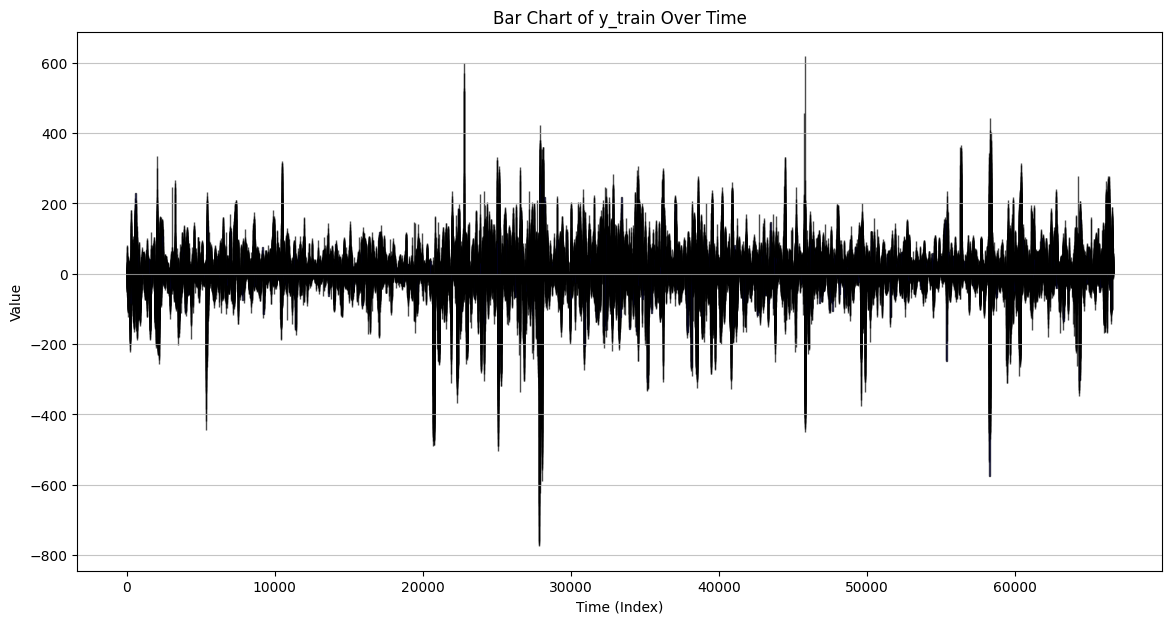

In [104]:
import matplotlib.pyplot as plt

# Plot bar chart for y_train over time
plt.figure(figsize=(14, 7))
plt.bar(y_train.index, y_train, color='blue', alpha=0.7, edgecolor='black')
plt.title('Bar Chart of y_train Over Time')
plt.xlabel('Time (Index)')
plt.ylabel('Value')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [105]:

X_train

,residual_diff,residual_std,residual_mean,residual_z_all,residual_z_selected,residual_z_selected_mns,residual_sign,corr_all,corr_selected,corr_selected_mns,...,std_selected_w1920,std_selected_w7680,std_selected_w30720,std_selected_mns_w30,std_selected_mns_w60,std_selected_mns_w120,std_selected_mns_w480,std_selected_mns_w1920,std_selected_mns_w7680,std_selected_mns_w30720
0,-0.012515,0.002487,-0.005171,14.435897,51.5,37.064103,18.5,0.524132,0.419122,-0.105009,...,0.001286,0.001104,0.001115,0.000392,0.000334,0.000282,0.000230,0.000140,0.000121,0.000132
1,-0.012616,0.002489,-0.004841,18.256410,48.0,29.743590,18.5,0.515330,0.414294,-0.101035,...,0.001286,0.001104,0.001115,0.000402,0.000334,0.000281,0.000230,0.000139,0.000121,0.000132
2,-0.010667,0.002262,-0.004013,24.666667,53.5,28.833333,17.5,0.506414,0.416122,-0.090292,...,0.001286,0.001104,0.001115,0.000403,0.000358,0.000292,0.000233,0.000140,0.000121,0.000132
3,-0.010289,0.002236,-0.004138,24.358974,52.0,27.641026,17.5,0.491788,0.417261,-0.074526,...,0.001286,0.001104,0.001115,0.000417,0.000359,0.000292,0.000232,0.000140,0.000121,0.000132
4,-0.010742,0.002210,-0.003835,25.974359,44.0,18.025641,17.5,0.479400,0.425993,-0.053407,...,0.001422,0.001239,0.001268,0.000154,0.000048,0.000010,0.000019,0.000004,-0.000013,-0.000021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66619,-0.024626,0.003856,0.001275,72.743590,77.0,4.256410,5.5,0.879556,0.081160,-0.798396,...,0.001522,0.001373,0.000998,-0.001511,-0.001411,-0.001361,-0.001766,-0.001130,-0.001006,-0.000613
66620,-0.023347,0.003647,0.001623,77.923077,76.5,-1.423077,8.5,0.879967,0.083481,-0.796487,...,0.001522,0.001373,0.000998,-0.001173,-0.001411,-0.001292,-0.001763,-0.001130,-0.001006,-0.000613
66621,-0.022155,0.003615,-0.000027,56.000000,61.0,5.000000,1.5,0.880082,0.634037,-0.246045,...,0.002466,0.002313,0.001682,-0.000755,-0.000533,-0.000567,-0.000460,-0.000185,-0.000066,0.000070
66622,-0.022627,0.003602,0.000443,62.205128,73.0,10.794872,2.5,0.880404,0.085893,-0.794511,...,0.001522,0.001373,0.000998,-0.001158,-0.001416,-0.001291,-0.001763,-0.001130,-0.001006,-0.000613


In [106]:
# import numpy as np
# import pandas as pd

# # Check for infinity values in X_train
# print("Checking for infinity values in X_train...")

# # Method 1: Check which rows contain infinity values
# inf_mask = np.isinf(X_train).any(axis=1)
# invalid_rows = X_train[inf_mask]

# print(f"Number of rows with infinity values: {inf_mask.sum()}")
# print(f"Total rows in X_train: {len(X_train)}")
# print(f"Percentage of rows with infinity: {inf_mask.sum() / len(X_train) * 100:.2f}%")

# if len(invalid_rows) > 0:
#     print("\nRows with infinity values:")
#     print(invalid_rows)
    
#     # Show which columns contain infinity values
#     inf_columns = X_train.columns[np.isinf(X_train).any(axis=0)]
#     print(f"\nColumns containing infinity values: {list(inf_columns)}")
    
#     # Count infinity values per column
#     inf_count_per_column = np.isinf(X_train).sum()
#     inf_count_per_column = inf_count_per_column[inf_count_per_column > 0]
#     print("\nInfinity count per column:")
#     for col, count in inf_count_per_column.items():
#         print(f"  {col}: {count}")
    
#     # Show first few rows with infinity for inspection
#     print(f"\nFirst 5 rows with infinity values:")
#     print(invalid_rows.head())
    
# else:
#     print("No infinity values found in X_train.")

# # Method 2: Check for both positive and negative infinity separately
# pos_inf_mask = np.isposinf(X_train).any(axis=1)
# neg_inf_mask = np.isneginf(X_train).any(axis=1)

# print(f"\nRows with positive infinity: {pos_inf_mask.sum()}")
# print(f"Rows with negative infinity: {neg_inf_mask.sum()}")

In [107]:

# # Drop columns with infinity values
# X_train = X_train.drop(columns=inf_columns)
# print(f"Columns with infinity values have been dropped. Remaining columns: {X_train.columns}")

In [108]:

# # Drop columns with infinity values
# X_test = X_test.drop(columns=inf_columns)
# print(f"Columns with infinity values have been dropped. Remaining columns: {X_test.columns}")

In [109]:

def model_evaluation(y_true, y_pred, dataset_type="Train",thres = 5,if_plot=True, if_stats=True):
    from sklearn.metrics import mean_squared_error, r2_score
    import matplotlib.pyplot as plt
    
    mse = mean_squared_error(y_true, y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    std = y_true.std()
    
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    relative_mae = mae / std if std != 0 else float('inf')
    relative_rmse = rmse / std if std != 0 else float('inf')
    
    # 存储每个百分位的结果
    percentiles = []
    true_means = []
    pred_means = []
    sample_counts = []
    
    for top_pct in np.arange(0.002, 0.5, 0.002):
        threshold = np.percentile(y_pred, (1-top_pct) * 100)  # 选择最大的top_pct比例
        mask = y_pred >= threshold
        filtered_y_true = y_true[mask]
        filtered_y_pred = y_pred[mask]
        
        if len(filtered_y_true) > 0:  # 确保有数据
            percentiles.append(top_pct)
            true_means.append(np.mean(filtered_y_true))
            pred_means.append(np.mean(filtered_y_pred))
            sample_counts.append(len(filtered_y_true))
    
    # 计算总体均值
    overall_true_mean = np.mean(y_true)
    overall_pred_mean = np.mean(y_pred)

    y_true_filtered = []
    for i in range(len(y_true)):
        if y_pred[i] >thres:
            y_true_filtered.append(y_true[i])
        

    
    # 绘制折线图
    if if_plot:
        plt.figure(figsize=(12, 8))
        
        # 主图：均值对比
        plt.subplot(2, 1, 1)
        plt.plot(percentiles, true_means, 'b-o', label=f'True Mean', linewidth=2, markersize=4)
        plt.plot(percentiles, pred_means, 'r-s', label=f'Pred Mean', linewidth=2, markersize=4)
        plt.axhline(y=overall_true_mean, color='blue', linestyle='--', alpha=0.7, 
                    label=f'Overall True Mean: {overall_true_mean:.4f}')
        plt.axhline(y=overall_pred_mean, color='red', linestyle='--', alpha=0.7,
                    label=f'Overall Pred Mean: {overall_pred_mean:.4f}')
        plt.axhline(y=10, color='black', linestyle='--', alpha=0.7,
                label=f'cost baseline: 10')
        
        plt.xlabel('Top Percentile Threshold')
        plt.ylabel('Mean Value')
        plt.title(f'{dataset_type} Set: Mean Values by Percentile Threshold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 副图：样本数量
        plt.subplot(2, 1, 2)
        plt.plot(percentiles, sample_counts, 'g-^', label='Sample Count', linewidth=2, markersize=4)
        plt.xlabel('Top Percentile Threshold')
        plt.ylabel('Sample Count')
        plt.title('Sample Count by Percentile Threshold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    if if_stats:
        # 输出基本评估指标
        print(f"{dataset_type} Set Evaluation:")
        print(f"  MAE: {mae:.4f}, Relative MAE: {relative_mae:.4f}")
        print(f"  RMSE: {rmse:.4f}, Relative RMSE: {relative_rmse:.4f}")
        print(f"  R²: {r2:.4f}")
        print(f"  Overall True Mean: {overall_true_mean:.4f}")
        print(f"  Overall Pred Mean: {overall_pred_mean:.4f}\n")
        
        # 输出百分位分析表
        percentile_df = pd.DataFrame({
            'Percentile': percentiles,
            'True_Mean': true_means,
            'Pred_Mean': pred_means,
            'Sample_Count': sample_counts,
            'Mean_Diff': np.array(pred_means) - np.array(true_means)
        })
        
        print(f"{dataset_type} Set Percentile Analysis:")
        print(percentile_df.round(4))
    return len(y_true_filtered), np.mean(y_true_filtered),

    # # return percentile_df

In [110]:
pca = PCA(n_components=0.99)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
shape_before = X_train.shape[1]
shape_after = X_train_pca.shape[1]
print(f"PCA reduced the number of features from {shape_before} to {shape_after}.")

PCA reduced the number of features from 160 to 28.


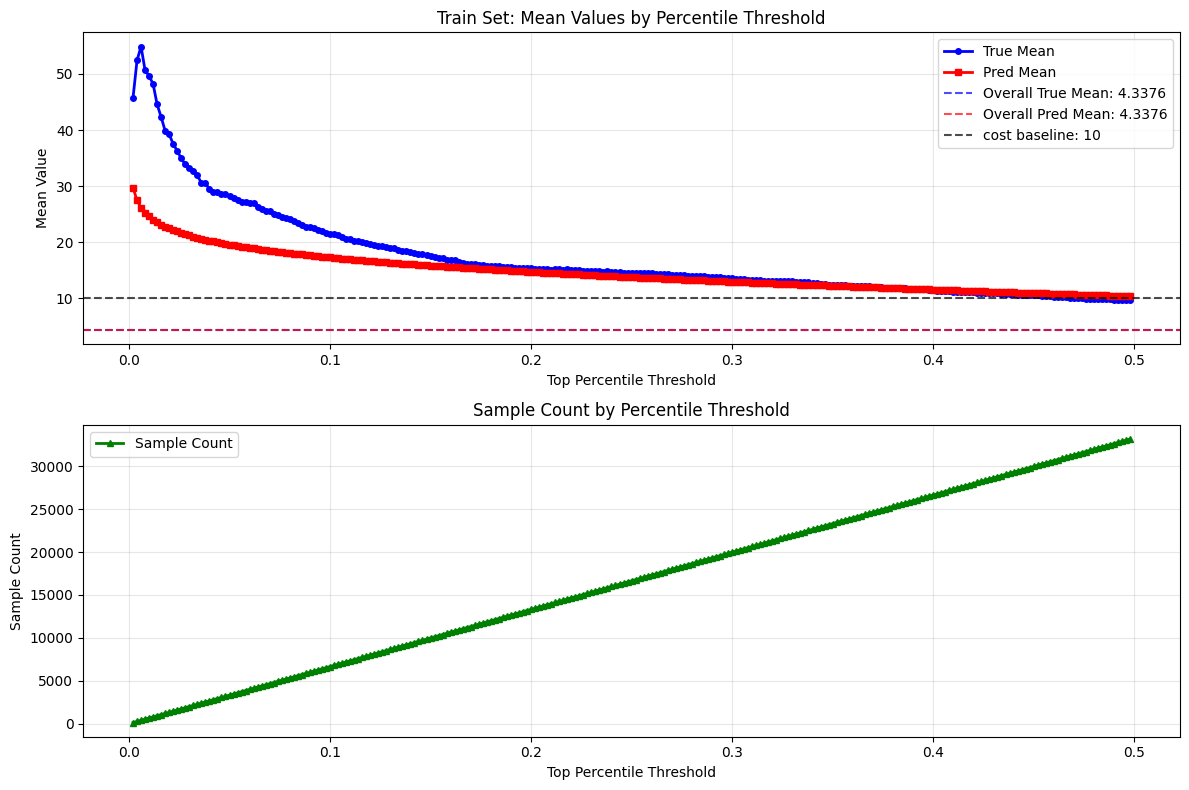

Train Set Evaluation:
  MAE: 46.2199, Relative MAE: 0.6677
  RMSE: 68.8102, Relative RMSE: 0.9941
  R²: 0.0118
  Overall True Mean: 4.3376
  Overall Pred Mean: 4.3376

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    45.7296    29.7491           134   -15.9804
1         0.004    52.4189    27.4428           267   -24.9761
2         0.006    54.9010    26.1737           400   -28.7273
3         0.008    50.6621    25.2769           533   -25.3852
4         0.010    49.6705    24.5951           667   -25.0754
..          ...        ...        ...           ...        ...
244       0.490     9.7657    10.4577         32646     0.6920
245       0.492     9.7462    10.4344         32779     0.6883
246       0.494     9.7072    10.4112         32912     0.7040
247       0.496     9.7126    10.3879         33046     0.6753
248       0.498     9.6748    10.3648         33179     0.6900

[249 rows x 5 columns]


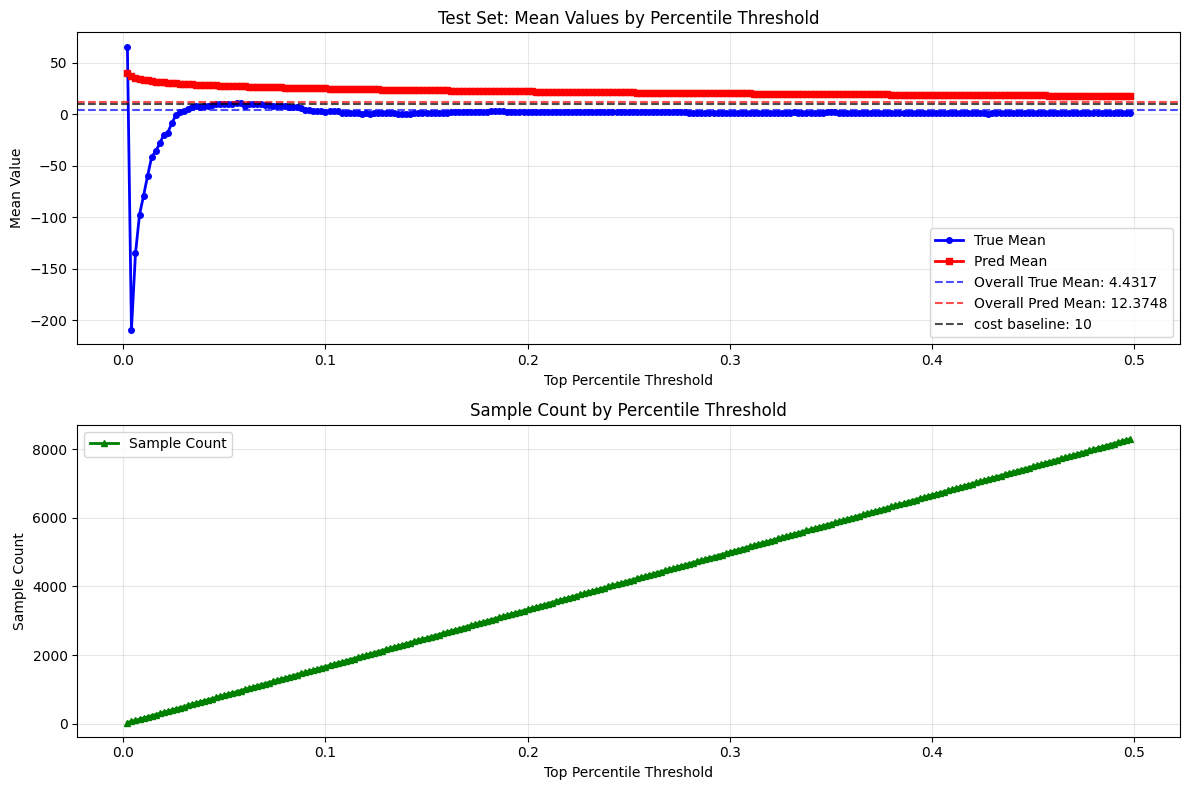

Test Set Evaluation:
  MAE: 56.4360, Relative MAE: 0.4606
  RMSE: 123.0654, Relative RMSE: 1.0044
  R²: -0.0088
  Overall True Mean: 4.4317
  Overall Pred Mean: 12.3748

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    65.9107    40.1610            34   -25.7498
1         0.004  -209.4166    37.2004            67   246.6170
2         0.006  -134.9079    35.6508           100   170.5587
3         0.008   -97.2674    34.4968           134   131.7642
4         0.010   -78.9812    33.6138           167   112.5950
..          ...        ...        ...           ...        ...
244       0.490     1.5830    17.9499          8161    16.3669
245       0.492     1.6793    17.9265          8195    16.2471
246       0.494     1.6656    17.9038          8228    16.2382
247       0.496     1.7064    17.8812          8261    16.1748
248       0.498     1.8020    17.8579          8295    16.0559

[249 rows x 5 columns]


(14443, np.float64(5.077099409927028))

In [111]:
linear_model = LinearRegression()

linear_model.fit(X_train_pca, y_train)

y_train_pred = linear_model.predict(X_train_pca)
y_test_pred = linear_model.predict(X_test_pca)
model_evaluation(y_train, y_train_pred, dataset_type="Train",thres=5)
model_evaluation(y_test, y_test_pred, dataset_type="Test",thres=5)

In [112]:

# ===============================
# 2. Ridge Pipeline（标准化 + Ridge）
# ===============================
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(
        alpha=1.0,          # L2 正则强度
        random_state=42
    ))
])

# ===============================
# 3. 训练
# ===============================
ridge_model.fit(X_train, y_train)

# ===============================
# 4. 预测 & 评估
# ===============================
y_train_pred = ridge_model.predict(X_train)
y_test_pred = ridge_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Train MSE: {train_mse:.6f}")
print(f"Test  MSE: {test_mse:.6f}")

# ===============================
# 5. 系数查看（Ridge 不会稀疏）
# ===============================
coef = ridge_model.named_steps["ridge"].coef_
coef_df = pd.Series(coef, index=X_train.columns).sort_values(key=np.abs, ascending=False)

print("\nTop coefficients by absolute value:")
print(coef_df.head(20))

Train MSE: 4335.715996
Test  MSE: 43372.916900

Top coefficients by absolute value:
residual_mean             82.428859
coef_adj_all              61.896056
bb_all_w30720             31.769260
std_all_w30720            23.725062
coef_adj_selected         23.611256
residual_diff            -22.959982
coef_adj_selected_mns    -18.829075
amihud_selected_w7680    -15.216690
amihud_selected_w30720    14.078108
residual_std             -13.399933
cmi_all_w7680             13.393607
atr_all_w480              13.277020
bb_all_w7680             -12.740925
amihud_all_w30720          9.896542
close_ret_all_w60          9.536625
std_selected_mns_w120     -9.258836
std_selected_w60           9.204047
std_all_w480              -8.843303
close_ret_selected_w60    -8.811881
atr_all_w30720             8.623669
dtype: float64


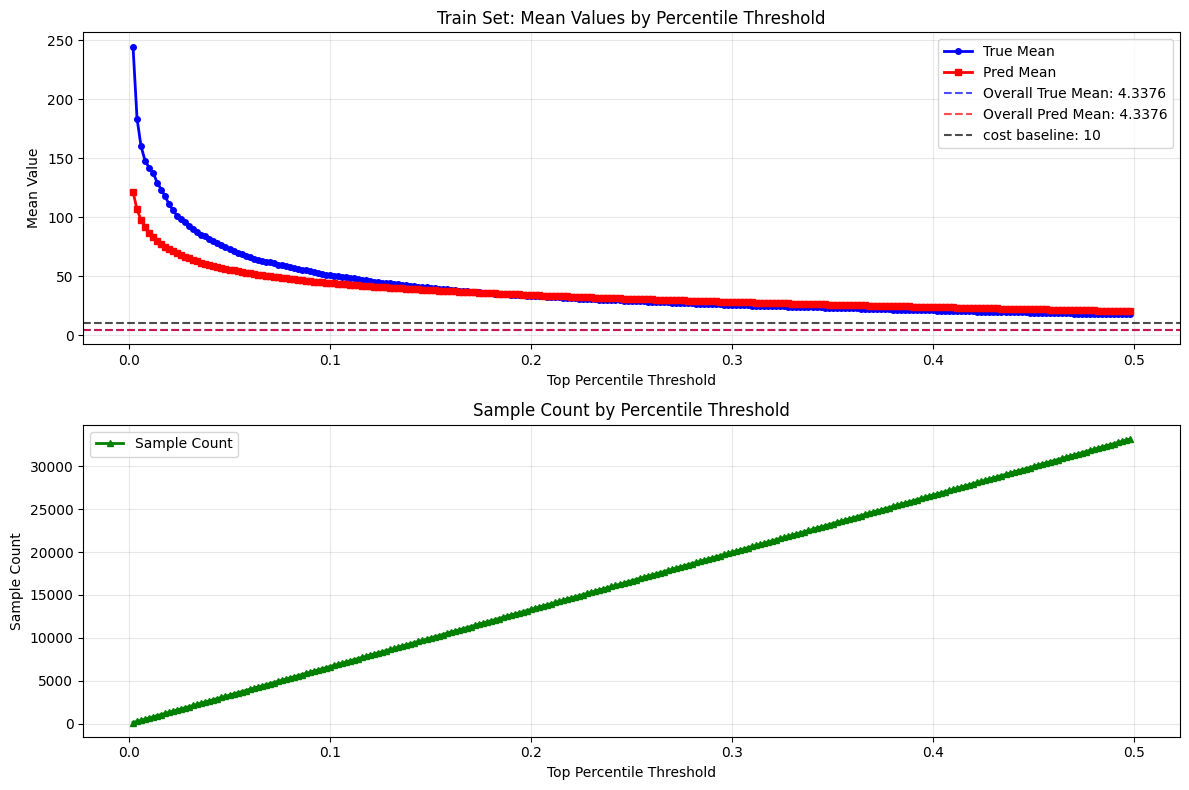

Train Set Evaluation:
  MAE: 45.3267, Relative MAE: 0.6548
  RMSE: 65.8462, Relative RMSE: 0.9512
  R²: 0.0951
  Overall True Mean: 4.3376
  Overall Pred Mean: 4.3376

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002   244.6208   121.5629           134  -123.0579
1         0.004   183.5935   106.5046           267   -77.0889
2         0.006   159.9847    97.6554           400   -62.3293
3         0.008   147.8534    91.5249           533   -56.3286
4         0.010   141.9496    86.8484           667   -55.1013
..          ...        ...        ...           ...        ...
244       0.490    17.7817    20.5766         32646     2.7949
245       0.492    17.7293    20.5090         32779     2.7797
246       0.494    17.6952    20.4417         32912     2.7464
247       0.496    17.6625    20.3740         33046     2.7115
248       0.498    17.6119    20.3069         33179     2.6951

[249 rows x 5 columns]


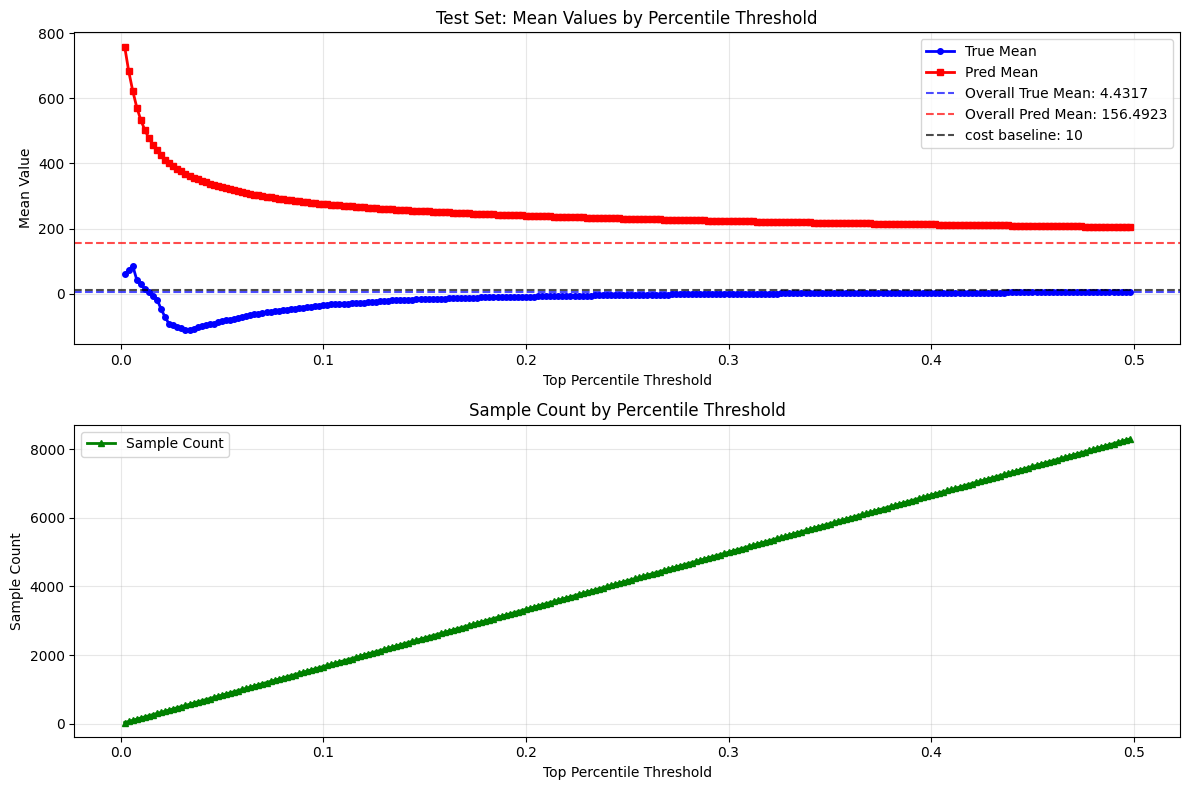

Test Set Evaluation:
  MAE: 159.7673, Relative MAE: 1.3039
  RMSE: 208.2617, Relative RMSE: 1.6997
  R²: -1.8890
  Overall True Mean: 4.4317
  Overall Pred Mean: 156.4923

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    60.4052   758.6637            34   698.2585
1         0.004    72.5030   682.8719            67   610.3690
2         0.006    85.7505   622.1290           100   536.3785
3         0.008    41.8992   571.3925           134   529.4934
4         0.010    28.7230   532.7252           167   504.0022
..          ...        ...        ...           ...        ...
244       0.490     3.9954   205.1042          8161   201.1088
245       0.492     3.9436   204.9422          8195   200.9986
246       0.494     3.9833   204.7852          8228   200.8019
247       0.496     3.9568   204.6283          8261   200.6716
248       0.498     3.9278   204.4669          8295   200.5391

[249 rows x 5 columns]


(16632, np.float64(4.333021265843138))

In [113]:

model_evaluation(y_train, y_train_pred, dataset_type="Train")
model_evaluation(y_test, y_test_pred, dataset_type="Test")

In [114]:
import numpy as np
import pandas as pd

# Check for infinity values in X_train
print("Checking for infinity values in X_train...")

# Method 1: Check which rows contain infinity values
inf_mask = np.isinf(X_train).any(axis=1)
invalid_rows = X_train[inf_mask]



Checking for infinity values in X_train...


In [115]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge.fit(X_train_80, y_train_80)

val_pred = ridge.predict(X_train_20)
print("Ridge val MSE:", mean_squared_error(y_train_20, val_pred))


Ridge val MSE: 4526.101250196421


In [116]:

# ===============================
# 1. 随机划分 80% / 20%（模拟你原来的 90/10 early stop）
# ===============================
split = int(0.8 * len(X_train))

X_train_80 = X_train.iloc[:split]
y_train_80 = y_train[:split]

X_train_20 = X_train.iloc[split:]
y_train_20 = y_train[split:]

# ===============================
# 2. 定义 LightGBM 回归模型
# ===============================
model = lgb.LGBMRegressor(
    objective="regression",
    metric="mse",
    boosting_type="gbdt",

    n_estimators=8000,
    learning_rate=0.05,

    num_leaves=127,          # 🔥 放开表达能力
    max_depth=-1,

    min_data_in_leaf=30,     # 🔥 关键：从 200 → 30
    min_gain_to_split=0.0,

    subsample=1.0,           # 🔥 先别采样
    subsample_freq=0,
    colsample_bytree=1.0,

    reg_lambda=0.5,          # 轻度 L2，别太狠

    n_jobs=-1,
    random_state=42,
    verbose=-1
)

# ===============================
# 3. 训练（Early Stopping）
# ===============================
print("Training LightGBM with early stopping...")

model.fit(
    X_train_80,
    y_train_80,
    eval_set=[(X_train_20, y_train_20)],
    eval_metric="mse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True)
    ]
)

# ===============================
# 4. 验证集评估
# ===============================
val_pred = model.predict(X_train_20, num_iteration=model.best_iteration_)
val_mse = mean_squared_error(y_train_20, val_pred)

print(f"Validation MSE: {val_mse:.6f}")
print(f"Best iteration: {model.best_iteration_}")

# ===============================
# 5. 全量预测
# ===============================
y_train_pred = model.predict(X_train, num_iteration=model.best_iteration_)
y_test_pred = model.predict(X_test, num_iteration=model.best_iteration_)

# ===============================
# 6. 可选：特征重要性
# ===============================
feature_importance = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)


Training LightGBM with early stopping...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's l2: 4436.33
Validation MSE: 4436.330021
Best iteration: 1


In [117]:
importance_df

,Feature,Importance
86,coin_selected_w480,5
156,std_selected_mns_w480,4
40,amihud_all_w30720,4
0,residual_diff,3
85,coin_selected_w120,3
...,...,...
90,coin_selected_mns_w30,0
41,amihud_selected_w30,0
42,amihud_selected_w60,0
87,coin_selected_w1920,0


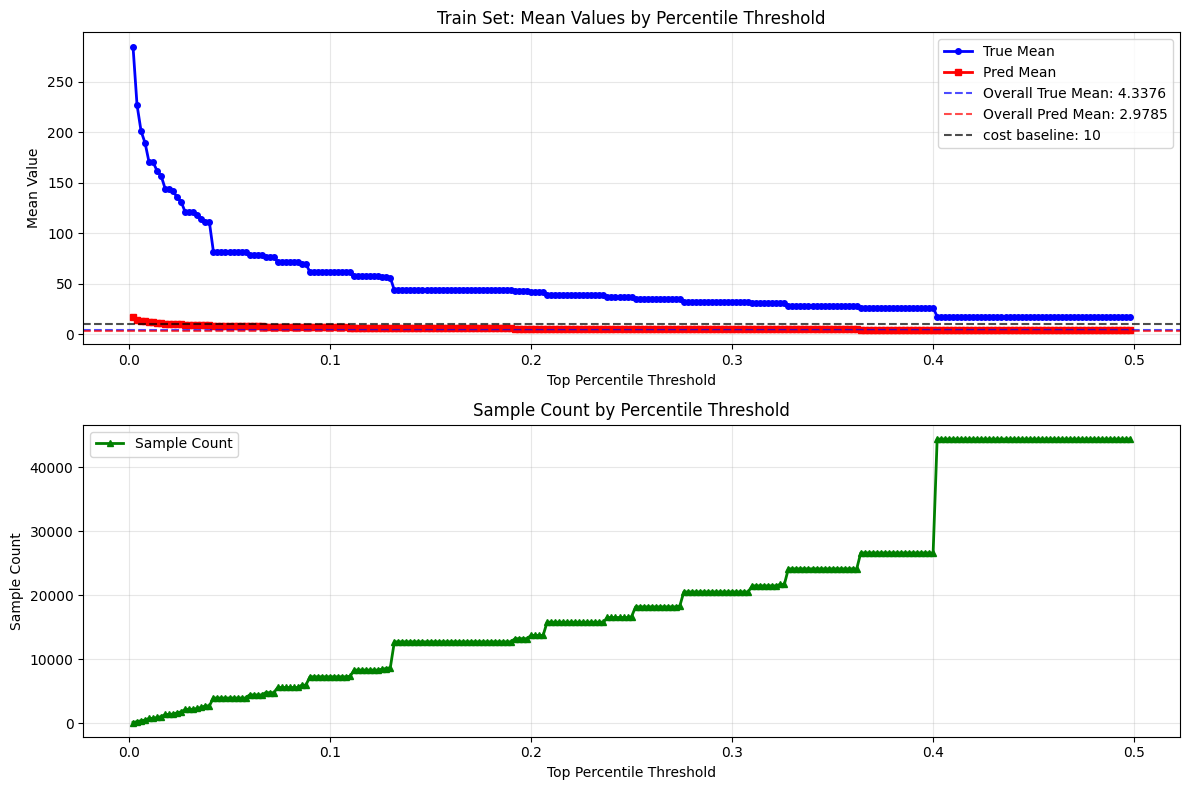

Train Set Evaluation:
  MAE: 45.8295, Relative MAE: 0.6621
  RMSE: 68.0222, Relative RMSE: 0.9827
  R²: 0.0343
  Overall True Mean: 4.3376
  Overall Pred Mean: 2.9785

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002   284.7410    16.9809           148  -267.7601
1         0.004   226.8432    14.2018           300  -212.6414
2         0.006   201.0515    13.1623           434  -187.8892
3         0.008   189.2652    12.5437           543  -176.7215
4         0.010   170.0176    11.6626           806  -158.3550
..          ...        ...        ...           ...        ...
244       0.490    17.3877     4.0122         44429   -13.3755
245       0.492    17.3877     4.0122         44429   -13.3755
246       0.494    17.3877     4.0122         44429   -13.3755
247       0.496    17.3877     4.0122         44429   -13.3755
248       0.498    17.3877     4.0122         44429   -13.3755

[249 rows x 5 columns]


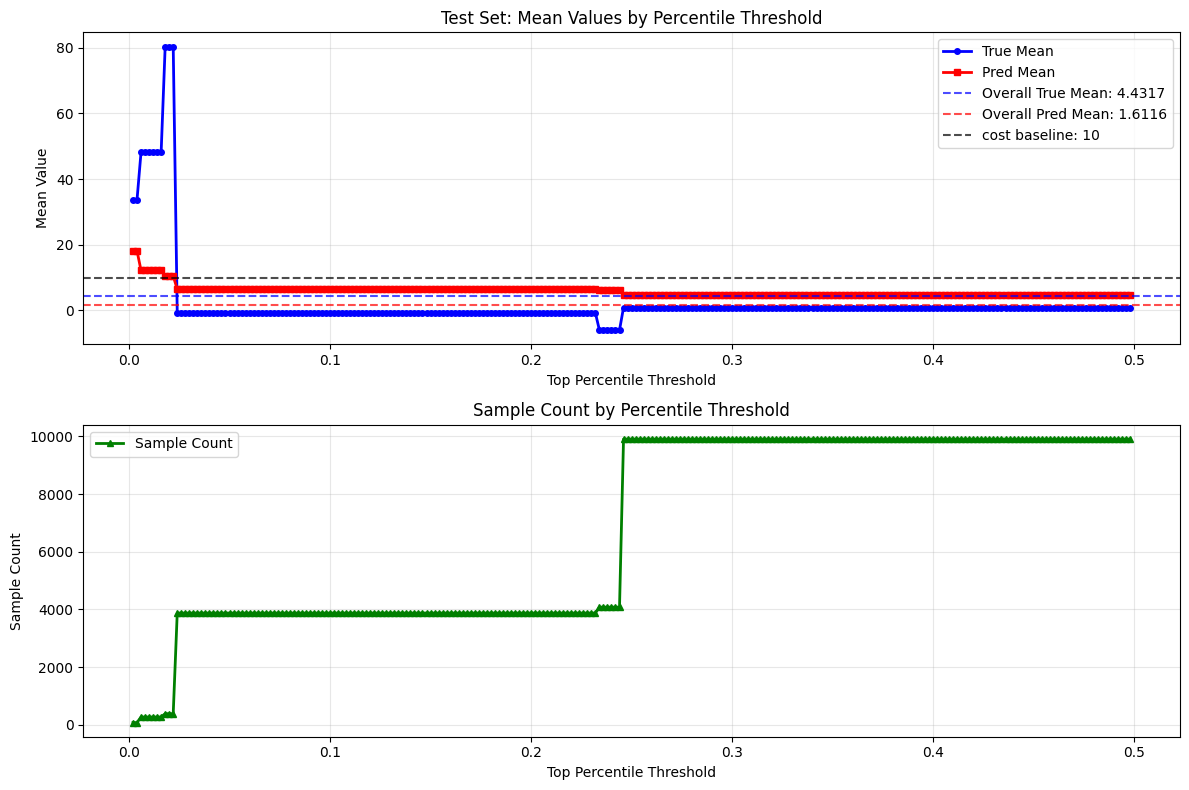

Test Set Evaluation:
  MAE: 56.3776, Relative MAE: 0.4601
  RMSE: 122.7214, Relative RMSE: 1.0016
  R²: -0.0032
  Overall True Mean: 4.4317
  Overall Pred Mean: 1.6116

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    33.7499    18.0787            75   -15.6712
1         0.004    33.7499    18.0787            75   -15.6712
2         0.006    48.2557    12.1469           269   -36.1088
3         0.008    48.2557    12.1469           269   -36.1088
4         0.010    48.2557    12.1469           269   -36.1088
..          ...        ...        ...           ...        ...
244       0.490     0.8629     4.6499          9912     3.7870
245       0.492     0.8629     4.6499          9912     3.7870
246       0.494     0.8629     4.6499          9912     3.7870
247       0.496     0.8629     4.6499          9912     3.7870
248       0.498     0.8629     4.6499          9912     3.7870

[249 rows x 5 columns]


(3876, np.float64(-0.7909229260972525))

In [118]:

model_evaluation(y_train, y_train_pred, dataset_type="Train")
model_evaluation(y_test, y_test_pred, dataset_type="Test")

In [119]:
# Resetting the index for X_train and y_train after slicing
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

In [120]:
# Identify columns where the name starts with 'coin', 'bb', or 'amihud'
columns_to_zero = [col for col in X_train.columns if col.startswith(('coin', 'bb', 'amihud'))]

# Set the entire column values to 0 for the identified columns
X_train[columns_to_zero] = 0

# Display the updated DataFrame
X_train['amihud_all_w30']

0        0
1        0
2        0
3        0
4        0
        ..
66619    0
66620    0
66621    0
66622    0
66623    0
Name: amihud_all_w30, Length: 66624, dtype: int64

In [121]:
import pickle
model = pickle.load(open('random_forest_model.pkl', 'rb'))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [122]:
# Multiply columns in X_train starting with 'amihud' by 10e6
amihud_columns = [col for col in X_train.columns if col.startswith('amihud')]
X_train[amihud_columns] *= 10e6

# Display the updated column to verify
X_train['amihud_all_w30']

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
66619    0.0
66620    0.0
66621    0.0
66622    0.0
66623    0.0
Name: amihud_all_w30, Length: 66624, dtype: float64

In [123]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Random Forest 参数设置
model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=10,
    min_samples_split=500,
    min_samples_leaf=250,
    
    max_samples=0.8,
    max_features=0.8,
    
    n_jobs=-1,
    random_state=42
)

# 数据分割
random_index = np.random.permutation(len(X_train))
split = int(0.8 * len(X_train))

X_train_80 = X_train.iloc[random_index[:split]]
y_train_80 = y_train[random_index[:split]]

X_train_20 = X_train.iloc[random_index[split:]]
y_train_20 = y_train[random_index[split:]]

# 训练模型
print("Training Random Forest...")
model.fit(X_train_80, y_train_80)

# 验证集评估
val_pred = model.predict(X_train_20)
val_mse = mean_squared_error(y_train_20, val_pred)
print(f"Validation MSE: {val_mse:.6f}")

# 全量预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 特征重要性
feature_importance = model.feature_importances_
feature_names = X_train.columns

print("Feature importance:")
for name, importance in zip(feature_names, feature_importance):
    print(f"  {name}: {importance:.4f}")

Training Random Forest...
Validation MSE: 3847.097405
Feature importance:
  residual_diff: 0.1722
  residual_std: 0.0058
  residual_mean: 0.0003
  residual_z_all: 0.0004
  residual_z_selected: 0.0001
  residual_z_selected_mns: 0.0003
  residual_sign: 0.0002
  corr_all: 0.0027
  corr_selected: 0.0030
  corr_selected_mns: 0.0070
  coef_adj_all: 0.0005
  coef_adj_selected: 0.0026
  coef_adj_selected_mns: 0.0054
  close_ret_all_w30: 0.0001
  close_ret_all_w60: 0.0009
  close_ret_all_w120: 0.0031
  close_ret_all_w480: 0.0032
  close_ret_all_w1920: 0.0585
  close_ret_all_w7680: 0.0080
  close_ret_all_w30720: 0.0100
  close_ret_selected_w30: 0.0003
  close_ret_selected_w60: 0.0019
  close_ret_selected_w120: 0.0028
  close_ret_selected_w480: 0.0158
  close_ret_selected_w1920: 0.0079
  close_ret_selected_w7680: 0.0059
  close_ret_selected_w30720: 0.0042
  close_ret_selected_mns_w30: 0.0162
  close_ret_selected_mns_w60: 0.0101
  close_ret_selected_mns_w120: 0.0902
  close_ret_selected_mns_w480: 

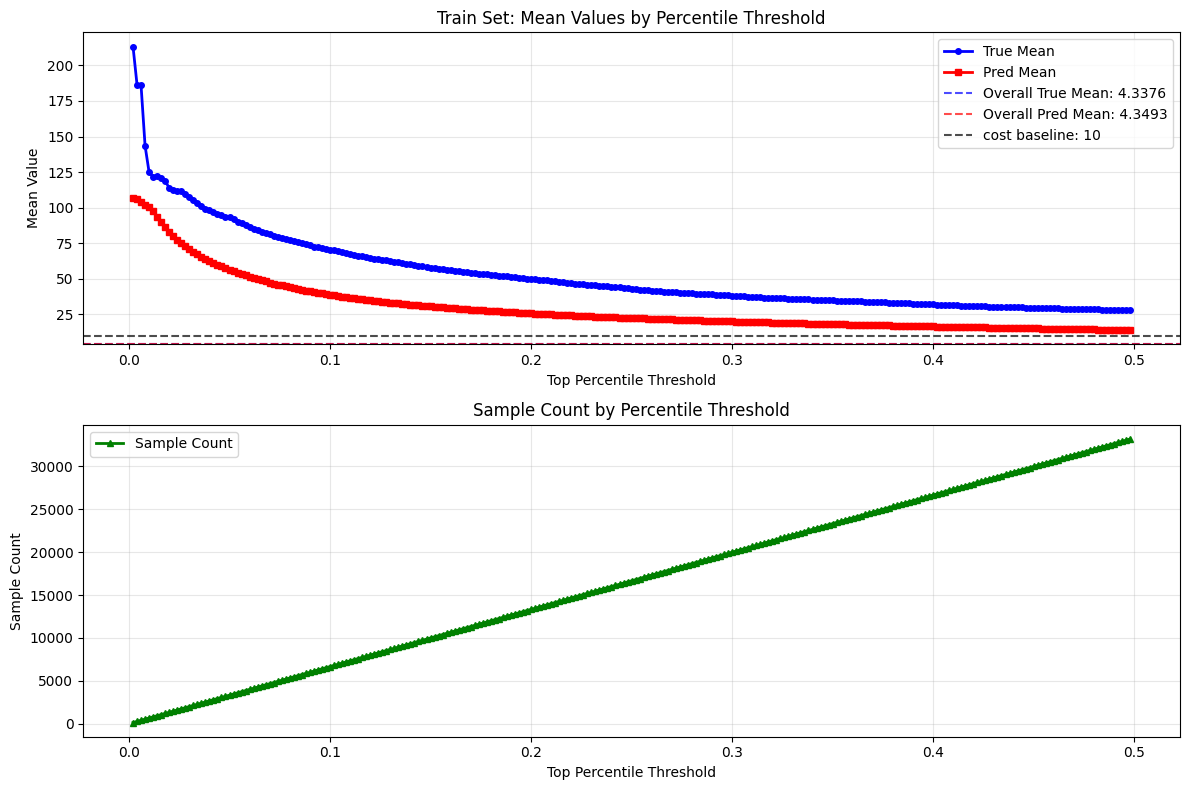

Train Set Evaluation:
  MAE: 42.5487, Relative MAE: 0.6147
  RMSE: 62.4413, Relative RMSE: 0.9021
  R²: 0.1863
  Overall True Mean: 4.3376
  Overall Pred Mean: 4.3493

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002   213.2625   107.0426           137  -106.2199
1         0.004   186.4330   106.3122           267   -80.1208
2         0.006   185.9352   103.9502           400   -81.9850
3         0.008   143.4900   102.0824           536   -41.4076
4         0.010   124.9245   100.6226           667   -24.3019
..          ...        ...        ...           ...        ...
244       0.490    28.1685    14.1776         32646   -13.9909
245       0.492    28.1115    14.1316         32779   -13.9799
246       0.494    28.0262    14.0859         32912   -13.9403
247       0.496    27.9725    14.0400         33046   -13.9325
248       0.498    27.9327    13.9947         33179   -13.9380

[249 rows x 5 columns]


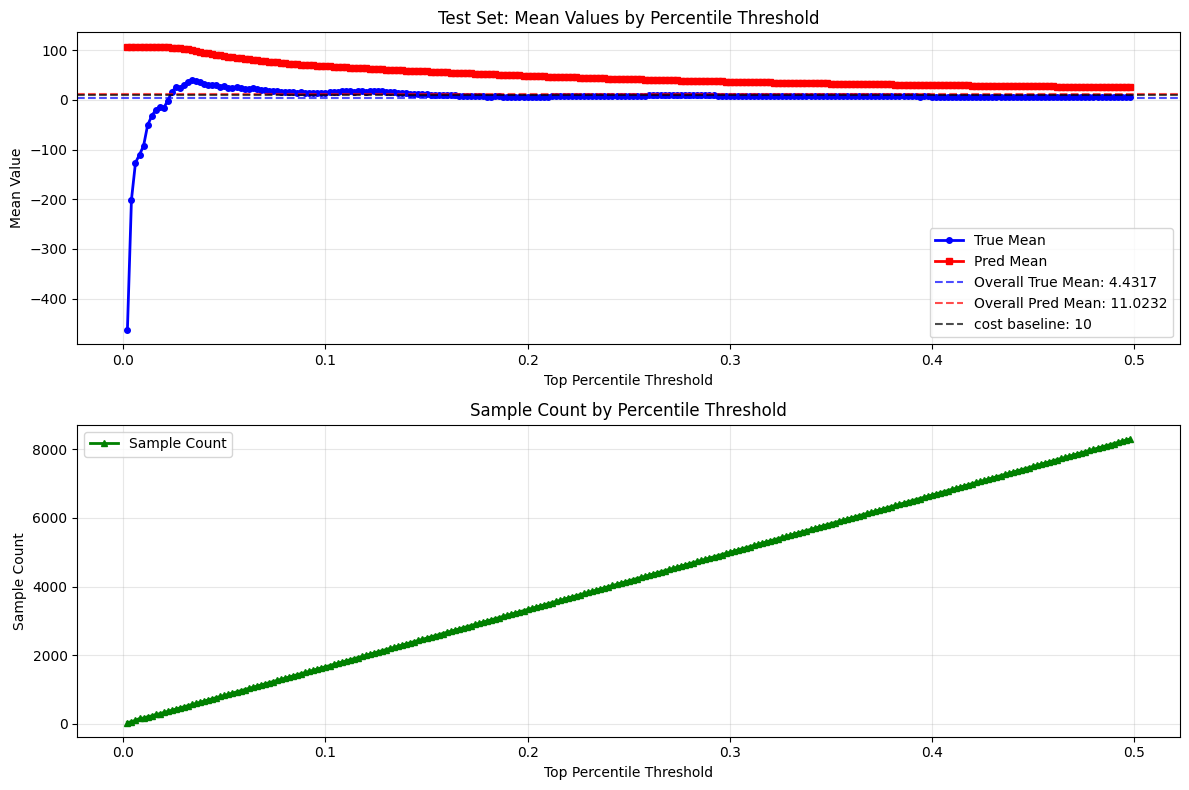

Test Set Evaluation:
  MAE: 57.1941, Relative MAE: 0.4668
  RMSE: 124.8237, Relative RMSE: 1.0187
  R²: -0.0378
  Overall True Mean: 4.4317
  Overall Pred Mean: 11.0232

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002  -463.0625   107.2156            41   570.2781
1         0.004  -200.9842   107.1639            67   308.1480
2         0.006  -126.4424   107.0373           107   233.4798
3         0.008  -110.2721   106.9208           159   217.1929
4         0.010   -92.5583   106.8950           173   199.4533
..          ...        ...        ...           ...        ...
244       0.490     6.4186    25.6232          8161    19.2046
245       0.492     6.3400    25.5430          8195    19.2030
246       0.494     6.1725    25.4656          8228    19.2931
247       0.496     6.2047    25.3888          8261    19.1840
248       0.498     6.2726    25.3101          8295    19.0375

[249 rows x 5 columns]


(9393, np.float64(4.774246598024089))

In [124]:

# 全量预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

model_evaluation(y_train, y_train_pred, dataset_type="Train")
model_evaluation(y_test, y_test_pred, dataset_type="Test")

In [125]:
# 特征重要性
feature_importance = model.feature_importances_
feature_names = X_train.columns

# Create a list of (name, importance) pairs and sort by importance (descending)
feature_importance_pairs = list(zip(feature_names, feature_importance))
feature_importance_pairs.sort(key=lambda x: x[1], reverse=True)

print("Feature importance (sorted by importance):")
for name, importance in feature_importance_pairs:
    print(f"  {name}: {importance:.4f}")

# Alternative: Create a DataFrame for easier manipulation
import pandas as pd

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
print(feature_importance_df.head(10).to_string(index=False))

Feature importance (sorted by importance):
  residual_diff: 0.1722
  close_ret_selected_mns_w120: 0.0902
  cmi_all_w1920: 0.0695
  close_ret_all_w1920: 0.0585
  std_all_w30720: 0.0423
  cmi_all_w30720: 0.0400
  cmi_all_w7680: 0.0335
  atr_all_w7680: 0.0314
  close_ret_selected_mns_w480: 0.0260
  atr_all_w30720: 0.0170
  close_ret_selected_mns_w30: 0.0162
  close_ret_selected_w480: 0.0158
  std_selected_mns_w1920: 0.0156
  std_selected_mns_w60: 0.0154
  cmi_all_w480: 0.0135
  cmi_selected_mns_w30720: 0.0115
  cmi_selected_w30720: 0.0114
  std_selected_mns_w120: 0.0111
  std_all_w7680: 0.0105
  std_selected_mns_w30: 0.0105
  close_ret_selected_mns_w60: 0.0101
  close_ret_all_w30720: 0.0100
  cmi_selected_w7680: 0.0099
  std_selected_w60: 0.0098
  close_ret_selected_mns_w7680: 0.0097
  std_selected_mns_w7680: 0.0096
  std_selected_mns_w480: 0.0092
  atr_all_w60: 0.0090
  std_all_w1920: 0.0088
  atr_all_w480: 0.0081
  close_ret_all_w7680: 0.0080
  close_ret_selected_w1920: 0.0079
  close_r

Average of non-zero true values (filtered by predicted > 20): 7.493697911105003
Percentage of non-zero true values (filtered by predicted > 20): 21.72790585975024


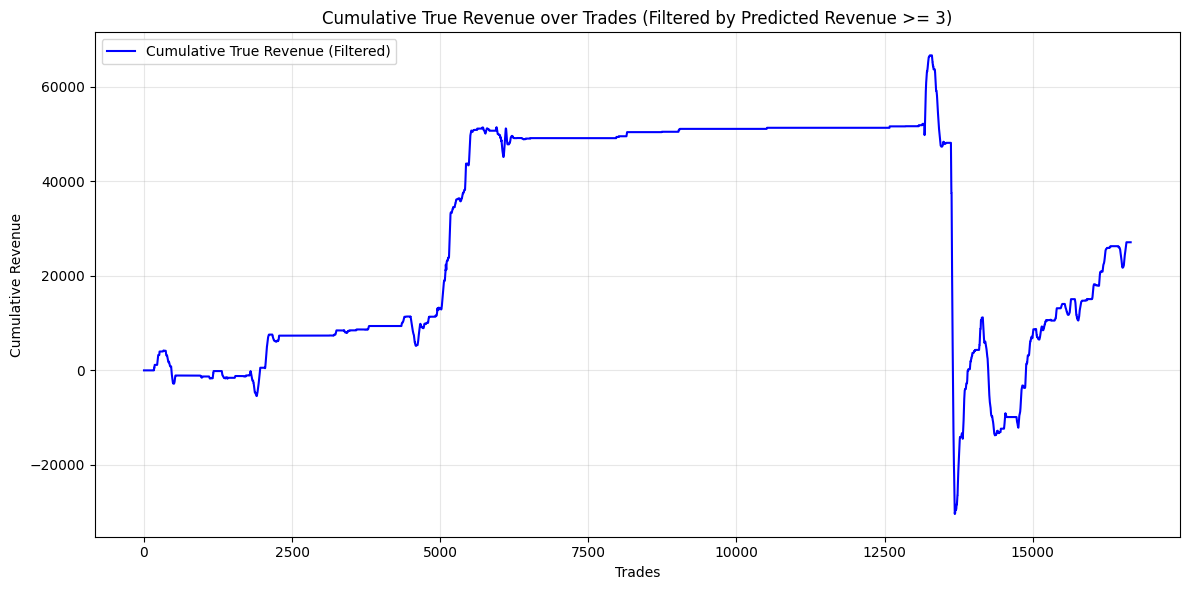

In [129]:
y_true_filtered = []
for i in range(len(y_test)):
    if y_test_pred[i] > 15:
        y_true_filtered.append(y_test[i])
    else:
        y_true_filtered.append(0)

non_zero_avg = np.mean([val for val in y_true_filtered if val != 0])
non_zero_pct = len([val for val in y_true_filtered if val != 0]) / len(y_true_filtered) * 100
print("Average of non-zero true values (filtered by predicted > 20):", non_zero_avg)
print("Percentage of non-zero true values (filtered by predicted > 20):", non_zero_pct)
y_true_filtered_cumsum = np.cumsum(y_true_filtered)

plt.figure(figsize=(12, 6))
plt.plot(y_true_filtered_cumsum, label='Cumulative True Revenue (Filtered)', color='blue')
plt.xlabel('Trades')
plt.ylabel('Cumulative Revenue')
plt.title('Cumulative True Revenue over Trades (Filtered by Predicted Revenue >= 3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [127]:
import pickle

# 保存模型
with open('random_forest_model_rct.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as random_forest_model.pkl")

Model saved as random_forest_model.pkl
